#**PREDICTION DU CHURN CLIENT**

##**Importation des bibliotheques**

In [57]:
import pandas as pd # Pour la manipulation et l'analyse de données tabulaires.
import numpy as np # Pour les opérations numériques et les calculs sur les tableaux.
import matplotlib.pyplot as plt # Pour la création de visualisations statiques, animées et interactives.
import seaborn as sns # Pour la création de visualisations statistiques attrayantes et informatives.

from sklearn.model_selection import train_test_split # Pour diviser les données en ensembles d'entraînement et de test.
from sklearn.preprocessing import StandardScaler # Pour la mise à l'échelle des caractéristiques (normalisation).
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc # Pour évaluer les performances du modèle de classification.
from sklearn.utils import class_weight # Pour calculer les poids des classes afin de gérer les déséquilibres.

import tensorflow as tf # Pour la construction et l'entraînement de réseaux de neurones.
from tensorflow.keras.models import Sequential # Pour créer un modèle de réseau de neurones couche par couche.
from tensorflow.keras.layers import Dense, Dropout # Couches de réseau de neurones (couches denses fully connected) et de régularisation (Dropout).
from tensorflow.keras.callbacks import EarlyStopping # Pour arrêter l'entraînement du modèle lorsque la performance cesse de s'améliorer.

##**Analyse Explorative(EDA)**

In [58]:
df = pd.read_csv("Telco-Customer-Churn.csv") # Charge le fichier CSV 'Telco-Customer-Churn.csv' dans un DataFrame pandas appelé 'df'. Ceci est l'ensemble de données brut à traiter.

In [73]:
# Aperçu des données
print("APERÇU DES DONNÉES")
print("Les 5 premières lignes :")
df.head()

APERÇU DES DONNÉES
Les 5 premières lignes :


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [76]:
# Informations générales sur le DataFrame
print("\nINFORMATIONS SUR LES COLONNES ")
df.info()
print("\nTAILLE DES DONNEES")
df.shape


INFORMATIONS SUR LES COLONNES 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7

(7043, 31)

In [77]:
# Statistiques descriptives pour les colonnes numériques
print("\n STATISTIQUES DESCRIPTIVES")
df.describe()


 STATISTIQUES DESCRIPTIVES


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [78]:
# Vérification des valeurs manquantes
print("\n VALEURS MANQUANTES PAR COLONNE ")
print(df.isnull().sum())


 VALEURS MANQUANTES PAR COLONNE 
SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes     


*** DISTRIBUTION DE LA VARIABLE CIBLE 'Churn' ***
Churn
0    5174
1    1869
Name: count, dtype: int64
En pourcentage :
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


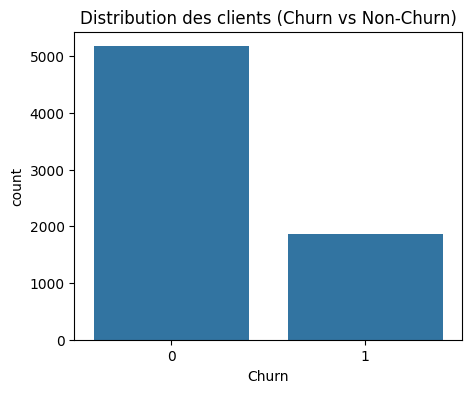

In [79]:
# Analyse de la variable cible 'Churn'
print("\n*** DISTRIBUTION DE LA VARIABLE CIBLE 'Churn' ***")
print(df['Churn'].value_counts())
print("En pourcentage :")
print(df['Churn'].value_counts(normalize=True) * 100)

# Visualisation
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn')
plt.title('Distribution des clients (Churn vs Non-Churn)')
plt.show()

##**Nettoyage et pretraitement des donnees des Donnees**

In [59]:
df.drop("customerID", axis=1, inplace=True) # Supprime la colonne 'customerID' car elle est un identifiant unique et n'est pas utile pour l'entraînement du modèle. 'inplace=True' modifie le DataFrame directement.

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce") # Convertit la colonne 'TotalCharges' en un type numérique. 'errors="coerce"' remplace les valeurs non convertibles par NaN.
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True) # Remplace les valeurs NaN (introduites par la conversion) dans 'TotalCharges' par la médiane de la colonne. Cela gère les valeurs manquantes.

df["Churn"] = df["Churn"].map({"Yes":1, "No":0}) # Convertit la colonne cible 'Churn' de valeurs textuelles ('Yes', 'No') en valeurs numériques (1, 0). C'est nécessaire pour l'entraînement du modèle.

df = pd.get_dummies(df, drop_first=True) # Effectue un encodage One-Hot pour les variables catégorielles restantes. 'drop_first=True' évite le problème de la multicolinéarité en supprimant la première catégorie de chaque variable encodée.

/tmp/ipython-input-226/4073222897.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True) # Remplace les valeurs NaN (introduites par la conversion) dans 'TotalCharges' par la médiane de la colonne. Cela gère les valeurs manquantes.


In [60]:
X = df.drop("Churn", axis=1) # Sépare les caractéristiques (variables indépendantes) de la variable cible. X contient toutes les colonnes sauf 'Churn'.
y = df["Churn"] # La variable cible (dépendante) 'Churn' est isolée dans y.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) # Divise les données en ensembles d'entraînement (80%) et de test (20%). 'random_state' assure la reproductibilité de la division.

In [61]:
scaler = StandardScaler() # Initialise un objet StandardScaler. Cet outil va normaliser les caractéristiques pour que leur moyenne soit 0 et leur écart-type 1.

X_train = scaler.fit_transform(X_train) # Ajuste le StandardScaler sur l'ensemble d'entraînement (calcule la moyenne et l'écart-type) et le transforme.
X_test = scaler.transform(X_test) # Transforme l'ensemble de test en utilisant les paramètres (moyenne, écart-type) calculés sur l'ensemble d'entraînement. C'est crucial pour éviter la fuite de données.

##**Entrainement du model**

In [62]:
weights = class_weight.compute_class_weight(
    class_weight="balanced", # Calcule les poids de classe de manière à ce que les classes soient équilibrées.
    classes=np.unique(y_train), # Utilise les classes uniques présentes dans l'ensemble d'entraînement.
    y=y_train # La variable cible de l'ensemble d'entraînement.
)

class_weights = {0: weights[0], 1: weights[1]} # Crée un dictionnaire pour les poids des classes, qui sera utilisé lors de l'entraînement du modèle pour gérer les déséquilibres.

print(class_weights) # Affiche les poids calculés pour chaque classe.

{0: np.float64(0.680763653939101), 1: np.float64(1.8830213903743316)}


In [63]:
model = Sequential() # Initialise un modèle de réseau de neurones séquentiel, où les couches sont ajoutées séquentiellement.

model.add(Dense(128, activation="relu", input_dim=X_train.shape[1])) # Ajoute la première couche dense (fully connected) avec 128 neurones et une fonction d'activation ReLU. 'input_dim' spécifie le nombre de caractéristiques d'entrée.
model.add(Dropout(0.4)) # Ajoute une couche Dropout avec un taux de 40% pour la régularisation, aidant à prévenir le surapprentissage.

model.add(Dense(64, activation="relu")) # Ajoute une deuxième couche dense avec 64 neurones et une activation ReLU.
model.add(Dropout(0.3)) # Ajoute une autre couche Dropout avec un taux de 30%.

model.add(Dense(32, activation="relu")) # Ajoute une troisième couche dense avec 32 neurones et une activation ReLU.

model.add(Dense(1, activation="sigmoid")) # Ajoute la couche de sortie avec 1 neurone et une fonction d'activation sigmoïde. C'est typique pour les problèmes de classification binaire, car la sigmoïde produit une probabilité entre 0 et 1.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
model.compile(
    optimizer="adam", # Configure l'optimiseur 'Adam', un algorithme d'optimisation populaire et efficace pour l'entraînement des réseaux de neurones.
    loss="binary_crossentropy", # Définit la fonction de perte comme 'binary_crossentropy', adaptée aux problèmes de classification binaire.
    metrics=["accuracy"] # Spécifie la métrique à surveiller pendant l'entraînement, ici l'exactitude (accuracy).
)

In [65]:
early_stop = EarlyStopping(
    monitor="val_loss", # Surveille la perte de validation. L'entraînement s'arrêtera si cette métrique ne s'améliore pas.
    patience=10, # Le nombre d'époques sans amélioration après lequel l'entraînement s'arrêtera.
    restore_best_weights=True # Restaure les poids du modèle à l'époque où la meilleure perte de validation a été observée.
) # Configure un callback d'Early Stopping pour arrêter l'entraînement si la perte de validation cesse de diminuer, afin de prévenir le surapprentissage.

In [66]:
history = model.fit(
    X_train, # Les caractéristiques de l'ensemble d'entraînement.
    y_train, # Les étiquettes (variable cible) de l'ensemble d'entraînement.
    epochs=100, # Le nombre maximal d'époques pour l'entraînement.
    batch_size=32, # La taille du lot (batch) utilisé pour chaque mise à jour des poids du modèle.
    validation_split=0.5, # Utilise 50% des données d'entraînement pour la validation pendant l'entraînement.
    class_weight=class_weights, # Applique les poids de classe calculés précédemment pour gérer le déséquilibre des classes.
    callbacks=[early_stop] # Utilise le callback d'Early Stopping pour arrêter l'entraînement si la perte de validation stagne.
) # Entraîne le modèle en utilisant les données d'entraînement, les hyperparamètres spécifiés et les callbacks.

Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6689 - loss: 0.6342 - val_accuracy: 0.7068 - val_loss: 0.5676
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7298 - loss: 0.5245 - val_accuracy: 0.7160 - val_loss: 0.5427
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7316 - loss: 0.5236 - val_accuracy: 0.7394 - val_loss: 0.5031
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7396 - loss: 0.5191 - val_accuracy: 0.7384 - val_loss: 0.5115
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7508 - loss: 0.4903 - val_accuracy: 0.7416 - val_loss: 0.5041
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7681 - loss: 0.4762 - val_accuracy: 0.7437 - val_loss: 0.5041
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7823 - loss: 0.4856 - val_accuracy: 0.7387 - val_loss: 0.5111
Epoch 8/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7748 - loss: 0.4784 - val_accuracy: 0.7334 - v

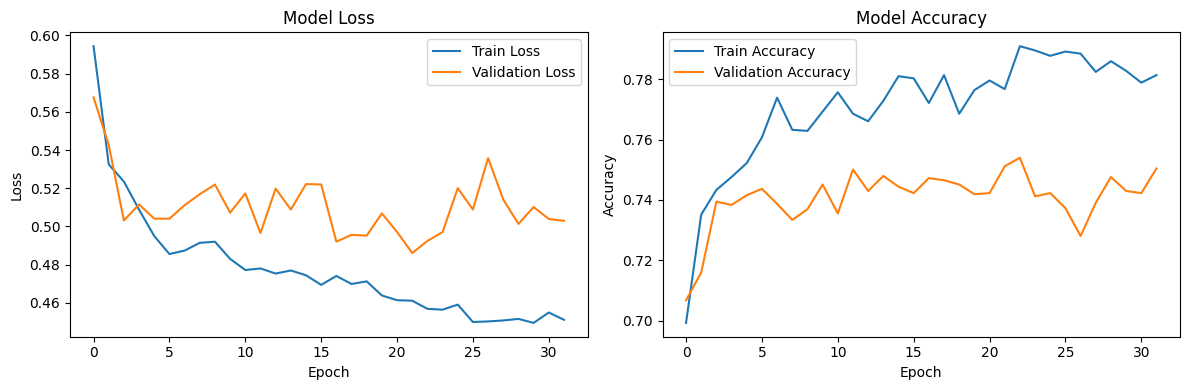

In [67]:
def plot_training_history(history): # Définit une fonction pour visualiser l'historique de l'entraînement du modèle.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4)) # Crée une figure avec deux sous-graphiques pour la perte et l'exactitude.

    # Loss
    ax1.plot(history.history['loss'], label='Train Loss') # Trace la perte d'entraînement par époque.
    ax1.plot(history.history['val_loss'], label='Validation Loss') # Trace la perte de validation par époque.
    ax1.set_title('Model Loss') # Définit le titre du graphique de perte.
    ax1.set_xlabel('Epoch') # Définit l'étiquette de l'axe X.
    ax1.set_ylabel('Loss') # Définit l'étiquette de l'axe Y.
    ax1.legend() # Affiche la légende.

    # Accuracy
    ax2.plot(history.history['accuracy'], label='Train Accuracy') # Trace l'exactitude d'entraînement par époque.
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy') # Trace l'exactitude de validation par époque.
    ax2.set_title('Model Accuracy') # Définit le titre du graphique d'exactitude.
    ax2.set_xlabel('Epoch') # Définit l'étiquette de l'axe X.
    ax2.set_ylabel('Accuracy') # Définit l'étiquette de l'axe Y.
    ax2.legend() # Affiche la légende.

    plt.tight_layout() # Ajuste automatiquement les paramètres du sous-graphique pour un affichage serré.
    plt.show() # Affiche les graphiques.

plot_training_history(history) # Appelle la fonction pour afficher les graphiques de l'historique d'entraînement du modèle.

In [68]:
loss, accuracy = model.evaluate(X_test, y_test) # Évalue la performance du modèle sur l'ensemble de test, retournant la perte et l'exactitude.
print("Accuracy:", accuracy) # Affiche l'exactitude du modèle sur l'ensemble de test.

y_pred_prob = model.predict(X_test) # Prédit les probabilités de désabonnement pour l'ensemble de test.
y_pred = (y_pred_prob > 0.5).astype("int32") # Convertit les probabilités en prédictions binaires (0 ou 1) en utilisant un seuil de 0.5.

print(confusion_matrix(y_test, y_pred)) # Affiche la matrice de confusion, qui résume les performances de classification du modèle.
print(classification_report(y_test, y_pred)) # Affiche un rapport de classification détaillé, y compris la précision, le rappel, le score F1 et le support pour chaque classe.

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7832 - loss: 0.4490
Accuracy: 0.7728886008262634
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[808 228]
 [ 92 281]]
              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1036
           1       0.55      0.75      0.64       373

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



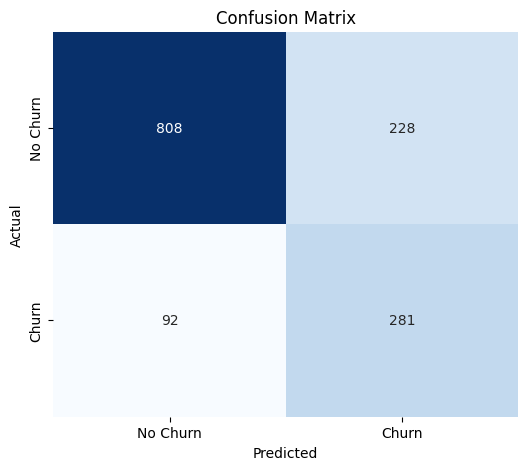

In [69]:
cm = confusion_matrix(y_test, y_pred) # Calcule la matrice de confusion entre les vraies étiquettes et les prédictions.
plt.figure(figsize=(6, 5)) # Crée une figure pour le graphique avec une taille spécifiée.
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, # Trace la matrice de confusion sous forme de heatmap avec les valeurs annotées.
            xticklabels=["No Churn", "Churn"], # Définit les étiquettes de l'axe X.
            yticklabels=["No Churn", "Churn"]) # Définit les étiquettes de l'axe Y.
plt.xlabel("Predicted") # Définit l'étiquette de l'axe X.
plt.ylabel("Actual") # Définit l'étiquette de l'axe Y.
plt.title("Confusion Matrix") # Définit le titre du graphique.
plt.show() # Affiche le graphique.

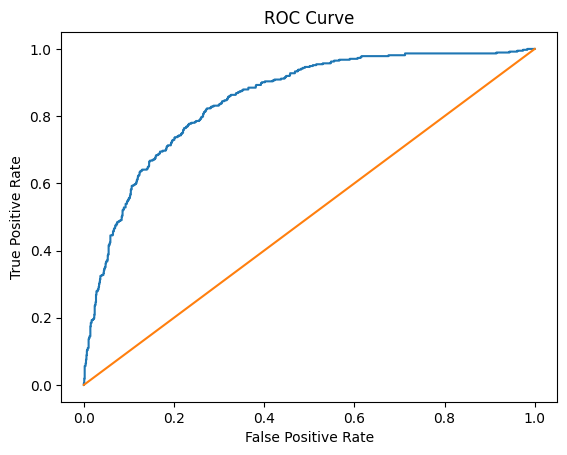

AUC: 0.8493988530851801


In [70]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob) # Calcule les taux de faux positifs (FPR), les taux de vrais positifs (TPR) et les seuils pour la courbe ROC.
roc_auc = auc(fpr, tpr) # Calcule l'aire sous la courbe ROC (AUC), une métrique de performance globale pour les classificateurs binaires.

plt.plot(fpr, tpr) # Trace la courbe ROC.
plt.plot([0,1],[0,1]) # Trace la ligne de référence (classificateur aléatoire).
plt.title("ROC Curve") # Définit le titre du graphique.
plt.xlabel("False Positive Rate") # Définit l'étiquette de l'axe X.
plt.ylabel("True Positive Rate") # Définit l'étiquette de l'axe Y.
plt.show() # Affiche le graphique.

print("AUC:", roc_auc) # Affiche la valeur de l'AUC.

##**Sauvegarde du model**

In [71]:
model.save("churn_model.h5") # Sauvegarde le modèle Keras entraîné dans un fichier au format HDF5. Cela permet de réutiliser le modèle sans avoir à le réentraîner.

##**Conclusion**


En conclusion, ce projet a permis de développer et d'évaluer un modèle de prédiction du désabonnement client qui démontre une bonne capacité globale à identifier les clients à risque. Avec une précision de 77.29% et un score AUC de 0.8494, le modèle est significativement plus performant qu'un classificateur aléatoire. Bien qu'il excelle à identifier les clients non-résilients, il atteint également un bon rappel (75%) pour la classe de désabonnement, ce qui est crucial pour les stratégies de rétention. Ce modèle constitue une base solide pour des interventions proactives visant à fidéliser la clientèle."

